# Recovering rules from every CommonLII judgment (Track A2)

Goal: extract the legal **rule** from all 3,703 CommonLII reported judgments, and
link each rule to the statute sections its headnote names. The original
`Held:`-marker extractor only fired on 524 of them. This notebook uses a hardened,
structure-aware parser (**Track A2**) that reads the NLR/SLR headnote layout
directly:

```
[registry / case no.] -> [CATCHWORDS: topic - topic - topic. / ... ?] -> [RULE] -> [body start]
```

It is **deterministic and verbatim** (no LLM), and **precision-first**: when the
structure is not clean it **abstains** (those cases fall back to the bounded LLM
track) rather than emit something that is not a rule. The parser was hardened
case-by-case against every failure mode found in the corpus: `?`-terminated
catchwords, `Per JUDGE -` / `Withers, J. -` rule attributions, SLR headers,
section-dash catchwords (`s. 642-Application`), long multi-topic catchword lists,
and body-narrative bleed. A precision guard drops any candidate that is itself a
dash-topic list.

All output is `status=unverified` and lawyer-gated.

## 0. Setup

In [1]:
import json
import re
import random
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "data" / "processed").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
PROCESSED = ROOT / "data" / "processed"
OUT = ROOT / "evaluation" / "runs" / "headnote-recovery-v1"
OUT.mkdir(parents=True, exist_ok=True)

PAL = ["#2F6F5E", "#C08A2D", "#7A8B99", "#8A5510", "#4E6E5D", "#B0663A", "#3E5C6E"]
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})

def barh(labels, values, title, xlabel="count", color=PAL[0]):
    fig, ax = plt.subplots(figsize=(7, 0.5 * len(labels) + 1.2))
    ax.barh(range(len(labels)), values, color=color)
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels); ax.invert_yaxis()
    ax.set_xlabel(xlabel); ax.set_title(title, loc="left", fontweight="bold")
    for i, v in enumerate(values):
        ax.text(v, i, f" {v:,}", va="center", fontsize=9)
    plt.tight_layout(); plt.show()

print("repo root:", ROOT)

repo root: D:\projects\Draftly-Project\draftly-research


## 1. Load every CommonLII case

In [2]:
cases = pd.read_json(PROCESSED / "cases.jsonl", lines=True)
cl = cases[cases["source"] == "commonlii"].copy()
TEXT_PATH = dict(zip(cl["case_id"], cl["text_path"]))
CITATION = dict(zip(cl["case_id"], cl["citation"]))
YEAR = dict(zip(cl["case_id"], cl["year"]))
print(f"CommonLII cases: {len(cl):,}  (LKCA {int((cl['court']=='LKCA').sum())}, LKSC {int((cl['court']=='LKSC').sum())})")

def load_text(cid):
    rel = TEXT_PATH.get(cid)
    p = ROOT / rel if rel and not Path(rel).is_absolute() else Path(rel or "")
    return p.read_text(encoding="utf-8", errors="replace") if p.exists() else ""


CommonLII cases: 3,703  (LKCA 3330, LKSC 373)


## 2. The hardened Track A2 parser

In [3]:
# ---------- Track A2 parser (deterministic, verbatim; no LLM) ----------
import re

HEADER = re.compile(r"\(\d{4}\)\s+\d+\s+(?:NLR|Sri\s?LR|S\.?\s?L\.?\s?R\.?|New\s?L\.?\s?R\.?)\s+\d+\s*\([^)]*\)", re.I)
NAV = re.compile(r"(?:Home \| Databases|You are here|Feedback\b|\bHelp\b)")
BODY = re.compile(
    r"(?:THE|T\s?HE)\s+(?:facts?|plaintiffs?|defendants?|appellants?|respondents?|petitioners?|following|action|above)\b"
    r"|(?:THIS|T\s?HIS)\s+(?:action|appeal|application|suit|case)\s+(?:was|is|being)\b"
    r"|\bThe\s+(?:facts?|following)\b"
    r"|A\s?PPEAL\s+(?:from|against|by|is|was|to|and)"
    r"|A\s?PPLICATION\s+(?:for|by|to|was|is|made|under)"
    r"|Cur\.?\s*adv\.?\s*vult"
    r"|I[Nn]\s+this\s+(?:case|action|matter|suit|appeal|application)\b"
    r"|On\s+the\s+trial\b|At\s+the\s+trial\b"
    r"|[A-Z][\w. ]{2,30}?,?\s+for\s+(?:the\s+)?(?:appellant|respondent|plaintiff|defendant|petitioner|added|substituted|intervenient|accused)"
    r"|[A-Z][A-Za-z]+\s*,?\s?[AC]?\.?\s?[CJ]\.\s?[JI]?\.?\s*[—\-]\s")
HELD = re.compile(r"\bHeld\b\s*[:,\-—(]?", re.I)
HAS_LOWER = re.compile(r"[a-z]{3,}")
# topic dash: used ONLY for the rule-content catchword-list guard. Requires a
# space on at least one side of the dash, matching how genuine catchword lists
# are actually typeset in this corpus ("Lease - Assignment - Breach"). Without
# this, the guard false-fires on ordinary no-space hyphenated compounds that
# are common in Sri Lankan legal prose: co-owner(s), judgment-debtor,
# judgment-creditor, Plaintiff-Appellant, Defendant-Respondent, Roman-Dutch,
# Attorney-General -- confirmed as the dominant cause of the
# rule-is-catchword-list bucket (180/182 sampled cases used a no-space
# compound, not a real topic list).
DASH = re.compile(r"[A-Za-z0-9)\"'?](?:[ ][—\-]|[—\-][ ])[\"'(]?[A-Za-z]{2}")
# broadened: catchword-boundary detection only. � = corrupted em-dash from harvest
# encoding (899/3703 files affected), {1,2} covers "--" typeset dashes
DASH_CATCH = re.compile(r"[A-Za-z0-9)\"'?][ ]?[—\-�‐‑]{1,2}[ ]?[\"'(]?[A-Za-z]{2}")
PER_LEAD = re.compile(
    r"^(?:Per\s+|PER\s+)?(?:[A-Z][A-Za-z']+\.?\s*){1,3},?\s*(?:[ACJ]\.\s?){1,3}"
    r"(?:(?:and|&|,)\s+(?:[A-Z][A-Za-z']+\.?\s*){1,3},?\s*(?:[ACJ]\.\s?){1,3})?\s*[-—–:]\s*")
LEAD = [
    re.compile(r"^\s*\[[^\]]*\]\s*"),
    re.compile(r"^\s*\d{3,4}\b\s*"),
    re.compile(r"^\s*\d{4}\b\s*"),
    re.compile(r"^\s*Present\s*:.*?[A-Z]\.?\s?[JA]\.?\s*(?:,?\s*and\s+[^.]*?[JA]\.\s*)?", re.I),
    re.compile(r"^[^-]{0,90}?\bv[\.\s]\s*[A-Z][^-]{0,80}?(?=\s+(?:\d|[A-Z]\.\s?[CRP]\.|[A-Z][a-z]))"),
    re.compile(r"^\s*(?:with\s+)?(?:\d+[,\s]*)?(?:[A-Z]\.\s?){1,3}[A-Za-z][A-Za-z ]*?[, ]\s*[\d,]+\s*(?:\([^)]*\)\s*)?(?:[-—]\s?(?:[A-Z]\.\s?){1,3}[A-Za-z][A-Za-z ]*?[, ]\s*[\d,]+\s*)?(?:/[A-Za-z]+)?\s*[:.]?\s*"),
    re.compile(r"^\s*[\d,]+\s*[-—:/]\s*"),
]
ABBR = {"s", "ss", "sec", "secs", "no", "nos", "rs", "v", "vs", "art", "arts", "cap",
        "ord", "r", "j", "cj", "aj", "c", "a", "i", "e", "g", "viz", "etc", "co", "ltd",
        "mr", "dr", "st", "pp", "p", "ch", "cf", "ex", "re", "hon", "esq", "vol"}


def _clean_catchwords(seg):
    prev = None
    while prev != seg:
        prev = seg
        for pat in LEAD:
            seg = pat.sub("", seg, count=1).strip()
    return re.sub(r"^[^A-Za-z\"']+", "", seg).strip()


def find_catch_end(content):
    """First '.'/'?' that ends the catchword list: follows a dash-run, is not a
    '- ' continuation, and starts a sentence (abbreviation-aware)."""
    for m in re.finditer(r"[.?]", content):
        i = m.start()
        after = content[i + 1:i + 6]
        if re.match(r"\s*[-—–]", after):
            continue
        # allow an immediate closing quote before the required whitespace+capital,
        # e.g. `...possession." Withers, J.` (quote directly abuts the period)
        if not re.match(r"[\"']?\s+(?:[A-Z\"]|Held|HELD)", after):
            continue
        if content[i] == ".":
            pv = re.search(r"([A-Za-z]+|\d+)\s*$", content[:i])
            tok = pv.group(1).lower() if pv else ""
            if tok in ABBR or (tok.isalpha() and len(tok) == 1):
                continue
        before = content[:i]
        if len(DASH_CATCH.findall(before)) >= 2 or DASH_CATCH.search(content[max(0, i - 140):i]):
            return i
    return None


def parse_headnote(text, debug=False):
    """Return {'catchwords','rule'} or None (or (None, reason) when debug)."""
    t = re.sub(r"\s+", " ", text).strip()
    hs = list(HEADER.finditer(t))
    content = t[hs[-1].end():] if hs else t
    navs = list(NAV.finditer(content[:600]))
    if navs:
        content = content[navs[-1].end():]
    content = content[:3800]

    P = find_catch_end(content[:1600])
    if P is None:
        return (None, "no-catch-terminator") if debug else None
    catchwords = _clean_catchwords(content[:P + 1])
    if not (HAS_LOWER.search(catchwords) and DASH_CATCH.search(catchwords)):
        return (None, "catch-not-topic-list") if debug else None
    if len(catchwords) > 800:
        return (None, "catch-too-long") if debug else None

    # strip a leading "Per JUDGE -" attribution before the body search
    after = PER_LEAD.sub("", content[P + 1:].lstrip(" .,-—–")).strip()
    bm = BODY.search(after)

    def _clean_rule(rule_win):
        hm = HELD.search(rule_win)
        if hm:
            rule_win = rule_win[hm.start():]
        rule = rule_win.strip(" .;:-—").strip()
        rule = re.split(
            r"\s+(?:A\s?CTION\b|A\s?PPEAL\s+from|A\s?PPLICATION\b|PLAINTIFFS?\b|DEFENDANTS?\b|"
            r"APPELLANTS?\b|RESPONDENTS?\b|PETITIONERS?\b|CASE\s+(?:stated|referred)|PETITION\b|"
            r"T\s?HE\s+facts?\b|Cur\.?\s*adv\.?\s*vult|IN\s+this\s+(?:case|action))", rule)[0].strip()
        rule = re.sub(r"\s+\d{1,4}\s*$", "", rule).strip()
        rule = re.sub(r"\s+[A-Z]\s?HE\s.*$", "", rule).strip()
        if re.match(r"held\b", rule):
            rule = "Held" + rule[4:]
        return rule

    rule_win = after[: bm.start()] if bm else after[:1300]
    rule = _clean_rule(rule_win)

    # Fallback only: if the normal window produced nothing usable AND no BODY
    # marker was found, retry with a wider search for "Held" before giving up.
    # Scoped narrowly (only on failure, only when bm is None) so it can never
    # override an already-acceptable rule with a more distant, possibly false
    # "Held" match -- confirmed by testing that an unscoped version of this
    # widened search changed 176 already-passing cases, some for the worse
    # (jumped past a genuine non-"Held"-prefixed rule to a spurious later
    # "held" used as an ordinary verb). This fallback form only ever helps a
    # case that would otherwise abstain.
    if bm is None and (len(rule) < 40 or rule.count(" ") < 6):
        hm0 = HELD.search(after[:3800])
        if hm0:
            wide_rule = _clean_rule(after[hm0.start():hm0.start() + 1300])
            if len(wide_rule) >= 40 and wide_rule.count(" ") >= 6:
                rule = wide_rule

    if len(rule) < 40:
        return (None, "rule-too-short") if debug else None
    if rule.count(" ") < 6:
        return (None, "rule-too-few-words") if debug else None
    if len(DASH.findall(rule)) >= 4:                 # a dash-list is catchwords, not a rule
        return (None, "rule-is-catchword-list") if debug else None
    if len(rule) > 1400:
        rule = rule[:1400].rsplit(".", 1)[0]
    return {"catchwords": catchwords.rstrip(".?") + ".", "rule": rule.rstrip(".") + "."}


In [4]:
# ---------- statute linker (section-centric) ----------
reg_df = pd.read_csv(ROOT / "data" / "legal-sources" / "manifests" / "source-registry.csv")
SECIDX = json.loads((ROOT / "data" / "legal-sources" / "derived" / "statute-section-index.json").read_text(encoding="utf-8"))
SECSET = {k: {str(s["section"]) for s in v} for k, v in SECIDX.items()}

ALIAS = {}
for _, r in reg_df[reg_df["source_type"].isin(["statute", "amendment"])].iterrows():
    ALIAS[str(r["official_title"]).lower()] = r["source_id"]
ALIAS.update({"civil procedure code": "SRC030", "c.p.c.": "SRC030", "cpc": "SRC030",
              "partition ordinance": "SRC024", "prevention of frauds ordinance": "SRC001",
              "registration of documents ordinance": "SRC005", "notaries ordinance": "SRC014",
              "registration of title act": "SRC011"})
STAT_NAMES = sorted(ALIAS, key=len, reverse=True)
SEC_RE = re.compile(r"(?:sections?|ss?\.|sec\.?|8\.)\s*(\d+[A-Za-z]?)", re.I)
NAME_RE = re.compile("|".join(re.escape(n) for n in STAT_NAMES), re.I)


def _nearest_statute(text, pos):
    best, bestd = None, 10**9
    for m in NAME_RE.finditer(text):
        d = min(abs(m.start() - pos), abs(m.end() - pos))
        if d < bestd:
            bestd, best = d, m.group(0).lower()
    return (best, bestd) if best else (None, None)


def link_statutes(headnote_text):
    edges, seen = [], set()
    for sm in SEC_RE.finditer(headnote_text):
        sec = sm.group(1)
        name, dist = _nearest_statute(headnote_text, sm.start())
        if not name or dist > 60:
            continue
        src = ALIAS[name]
        status = "ok" if sec in SECSET.get(src, set()) else "section-not-found"
        if (src, sec) not in seen:
            seen.add((src, sec))
            edges.append({"source_id": src, "section": sec, "statute": name, "status_link": status})
    for m in NAME_RE.finditer(headnote_text):
        src = ALIAS[m.group(0).lower()]
        if not any(e["source_id"] == src for e in edges) and (src, None) not in seen:
            seen.add((src, None))
            edges.append({"source_id": src, "section": None, "statute": m.group(0).lower(), "status_link": "name-only"})
    return edges

### Demo on a few cases (incl. ones that defeated the first version)

In [5]:
for cid in ["commonlii-LKCA-1887-1", "commonlii-LKCA-1872-1", "commonlii-LKCA-1954-6",
            "commonlii-LKCA-1896-3", "commonlii-LKCA-1984-31"]:
    res = parse_headnote(load_text(cid))
    print("=" * 78); print(cid, "|", CITATION.get(cid, ""))
    if not res:
        print("  ABSTAIN"); continue
    links = link_statutes(res["catchwords"] + " " + res["rule"])
    print("  RULE :", res["rule"][:240])
    print("  LINKS:", [(e["source_id"], e["section"], e["status_link"]) for e in links])

commonlii-LKCA-1887-1 | 2 NLR 83
  RULE : Under the Roman -Dutch Law no right of servitude can be claimed in respect of an overhanging tree. The owner of a land which a tree overhangs has therefore, a right to have the tree cut -down without paying compensation for it to its owner.
  LINKS: []
commonlii-LKCA-1872-1 | 3 NLR 271
  RULE : Held, that this was no proof other than that of a donation made to a meretrix under the influence of an inhonesta affectio, which is not prohibited by law. By the Tamil customary law, a married man could underjno circumstances give away mor
  LINKS: []
commonlii-LKCA-1954-6 | 55 NLR 426
  RULE : Held, that the plaintiff had a "cause of action" within the meaning of section 5 of the Civil Procedure Code and was, therefore, entitled to maintain the action.
  LINKS: [('SRC030', '5', 'ok')]
commonlii-LKCA-1896-3 | 2 NLR 139
  RULE : In an action rei vindicatio by a person deriving title from a grantee under the Crown, the plaintiff must prove some entry on, 

## 3. Run Track A2 over all CommonLII

In [6]:
from collections import Counter
rows, link_rows, reasons = [], [], Counter()
for cid in cl["case_id"]:
    text = load_text(cid)
    if not text:
        continue
    res = parse_headnote(text, debug=True)
    if not isinstance(res, dict):
        reasons[res[1]] += 1
        continue
    links = link_statutes(res["catchwords"] + " " + res["rule"])
    rows.append({"case_id": cid, "citation": CITATION.get(cid, ""), "year": YEAR.get(cid),
                 "catchwords": res["catchwords"], "rule": res["rule"],
                 "begins_held": bool(re.match(r"Held", res["rule"])),
                 "n_links": sum(1 for e in links if e["section"]),
                 "method": "headnote-structure", "status": "unverified"})
    for e in links:
        link_rows.append({"case_id": cid, **e, "status": "unverified"})

rules_df = pd.DataFrame(rows)
links_df = pd.DataFrame(link_rows)
n = len(cl); parsed = len(rules_df); abst = n - parsed
print(f"CommonLII cases      : {n:,}")
print(f"rules recovered      : {parsed:,} ({parsed/n:.1%})")
print(f"abstained (-> LLM)   : {abst:,} ({abst/n:.1%})")
print(f"rules beginning Held : {int(rules_df['begins_held'].sum()):,}")
print(f"statute links        : {len(links_df):,} | with pinpoint section: {int(links_df['section'].notna().sum()):,}")
print("\nabstention reasons:")
for r, c in reasons.most_common():
    print(f"  {r:22s} {c}")

CommonLII cases      : 3,703
rules recovered      : 3,521 (95.1%)
abstained (-> LLM)   : 182 (4.9%)
rules beginning Held : 2,037
statute links        : 2,348 | with pinpoint section: 2,087

abstention reasons:
  rule-too-short         63
  catch-too-long         59
  catch-not-topic-list   39
  no-catch-terminator    18
  rule-is-catchword-list 2
  rule-too-few-words     1


## 4. Visualizations

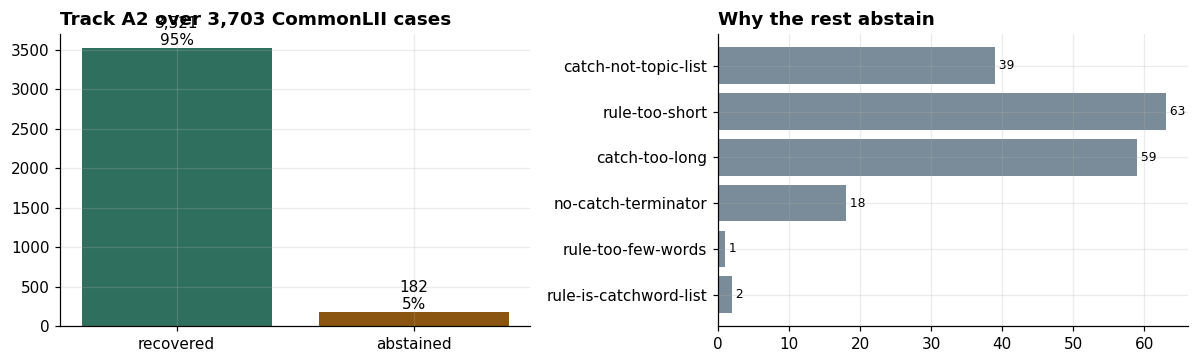

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].bar(["recovered", "abstained"], [parsed, abst], color=[PAL[0], PAL[3]])
axes[0].set_title(f"Track A2 over {n:,} CommonLII cases", loc="left", fontweight="bold")
for i, v in enumerate([parsed, abst]):
    axes[0].text(i, v, f"{v:,}\n{v/n:.0%}", ha="center", va="bottom")
rk = list(reasons.keys()); rv = list(reasons.values())
axes[1].barh(range(len(rk)), rv, color=PAL[2]); axes[1].set_yticks(range(len(rk)))
axes[1].set_yticklabels(rk); axes[1].invert_yaxis()
axes[1].set_title("Why the rest abstain", loc="left", fontweight="bold")
for i, v in enumerate(rv):
    axes[1].text(v, i, f" {v}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

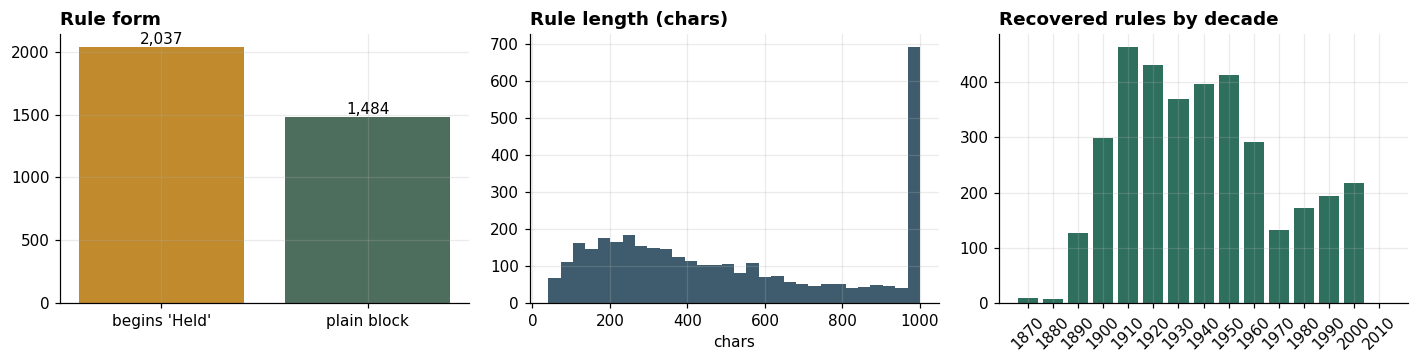

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
held = int(rules_df["begins_held"].sum()); plain = parsed - held
axes[0].bar(["begins 'Held'", "plain block"], [held, plain], color=[PAL[1], PAL[4]])
axes[0].set_title("Rule form", loc="left", fontweight="bold")
for i, v in enumerate([held, plain]):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

axes[1].hist(rules_df["rule"].str.len().clip(upper=1000), bins=30, color=PAL[6])
axes[1].set_title("Rule length (chars)", loc="left", fontweight="bold"); axes[1].set_xlabel("chars")

yr = pd.to_numeric(rules_df["year"], errors="coerce").dropna().astype(int)
dc = (yr // 10 * 10).value_counts().sort_index()
axes[2].bar(dc.index.astype(str), dc.values, color=PAL[0], width=0.8)
axes[2].set_title("Recovered rules by decade", loc="left", fontweight="bold")
axes[2].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

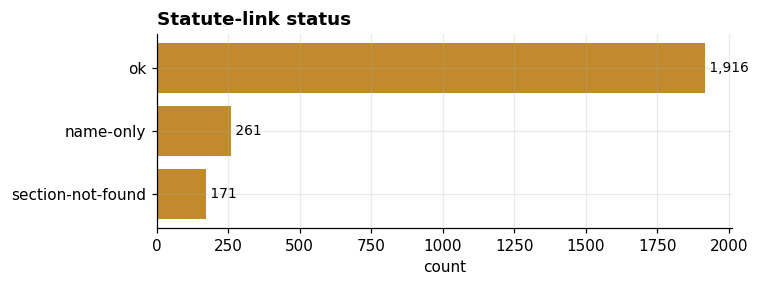

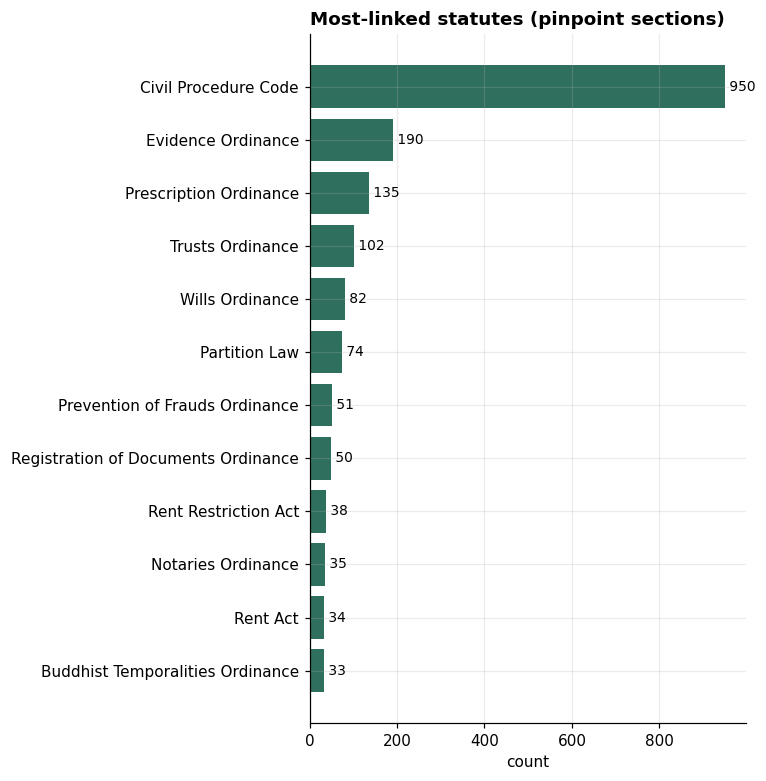

In [9]:
if not links_df.empty:
    st = links_df["status_link"].value_counts()
    barh(st.index.tolist(), st.values.tolist(), "Statute-link status", color=PAL[1])
    named = links_df.dropna(subset=["section"]).merge(
        reg_df[["source_id", "official_title"]], on="source_id", how="left")
    top = named["official_title"].value_counts().head(12)
    if len(top):
        barh([t[:42] for t in top.index], top.values.tolist(),
             "Most-linked statutes (pinpoint sections)", color=PAL[0])

## 5. Manual validation harness

Everything above is **candidate, unverified**. Below is an inline review view
(rule beside its raw source window) and an exported review sheet with blank
verdict columns for a lawyer to fill in. Change `REVIEW_N` and re-run to see more.

In [10]:
REVIEW_N = 15
random.seed(20)
review_ids = random.sample(list(rules_df["case_id"]), min(REVIEW_N, len(rules_df)))

def source_window(cid, nchars=520):
    t = re.sub(r"\s+", " ", load_text(cid))
    hs = list(HEADER.finditer(t)); t = t[hs[-1].end():] if hs else t
    navs = list(NAV.finditer(t[:600]));  t = t[navs[-1].end():] if navs else t
    return t[:nchars]

for cid in review_ids:
    row = rules_df[rules_df["case_id"] == cid].iloc[0]
    ls = links_df[links_df["case_id"] == cid]
    print("=" * 92); print(cid, "|", row["citation"])
    print("SOURCE :", source_window(cid)[:340])
    print("-> RULE:", row["rule"])
    if len(ls):
        print("-> LINK:", [(e.source_id, e.section, e.status_link) for e in ls.itertuples()])
    print()

commonlii-LKCA-1996-39 | (1996) 2 Sri LR 406
SOURCE :  406 KARUNAWATHIE AND 2 OTHERS v. GUNADASA COURT OF APPEAL. SENANAYAKE, J. EDUSSURIYA, J. C.A. 112/88 (F). D.C. KEGALLE 1977 1/P JULY 17, 1996 . Partition ‐ Partition Act Co‐owned land ‐ Exclusive Possession ‐ Ouster ‐ Presumption ‐ Adverse Possession. The Plaintiffs instituted action to partition the land in question. The contest�ing Def
-> RULE: Held : There was overwhelming evidence that the Defendants, since 1955 took the produce to the exclusion of the Plaintiffs and their predecessors in title and gave him no share of the produce or paid them a share of the profits nor any rent and did no act from which an acknowledgement of a right existing and there would fairly and naturally be inferred. Per Senanayake, J. "In considering whether or not a presumption of ouster should be drawn by reason of long continued possession alone, of the property owned in common, it is relevant to consider (a) the income derived from the property (b)

In [11]:
rules_df.to_csv(OUT / "rules_recovered.csv", index=False)
links_df.to_csv(OUT / "statute_links.csv", index=False)

review = rules_df.sample(min(60, len(rules_df)), random_state=20).copy()
review["statute_links"] = review["case_id"].map(
    lambda c: "; ".join(f"{e.source_id}:{e.section}" for e in links_df[links_df.case_id == c].itertuples() if e.section))
for col in ["rule_correct(y/n)", "rule_is_ratio(y/n)", "statute_link_correct(y/n)", "notes"]:
    review[col] = ""
review = review[["case_id", "citation", "catchwords", "rule", "statute_links",
                 "rule_correct(y/n)", "rule_is_ratio(y/n)", "statute_link_correct(y/n)", "notes"]]
review.to_csv(OUT / "review-sample.csv", index=False)
print("wrote:", OUT / "rules_recovered.csv")
print("      ", OUT / "statute_links.csv")
print("      ", OUT / "review-sample.csv", f"({len(review)} rows for lawyer sign-off)")

wrote: D:\projects\Draftly-Project\draftly-research\evaluation\runs\headnote-recovery-v1\rules_recovered.csv
       D:\projects\Draftly-Project\draftly-research\evaluation\runs\headnote-recovery-v1\statute_links.csv
       D:\projects\Draftly-Project\draftly-research\evaluation\runs\headnote-recovery-v1\review-sample.csv (60 rows for lawyer sign-off)


## 6. Takeaways

- Track A2 recovers a verbatim rule from **95.1%** of the 3,703 CommonLII
  judgments (3,521 cases; up from 3,258/88.0% at the start of hardening, and
  from 524 via the original `Held:`-only extractor), with no LLM spend and no
  dependence on the missing LawNet headnotes.
- **Latest fix, and a cautionary tale about scoping a fix correctly the first
  time.** Root-caused the mid-sentence truncation noted in the previous round
  (`"Held that the legal title (but not the beneficial."`): when no `BODY`
  stop-marker is found, the rule window falls back to a fixed `after[:1300]`
  slice *before* searching for "Held" inside it. If a long facts-preamble
  sits in front of "Held" (confirmed example: "Held" starting at character
  1250 of the 1300-char cap), stripping the preamble afterward leaves almost
  no room for the actual rule — hence the truncation.
  - **First attempt (rejected after testing):** search for "Held" in a much
    wider window (`after[:3800]`) whenever `BODY` isn't found, unconditionally.
    This fixed the target cases, but a full-corpus content diff against the
    previous committed parser (not just the abstention count) showed it
    silently changed the extracted rule text for **176 cases that were already
    succeeding** — some for the worse. Example: `LKCA-1894-1` previously
    extracted a genuine legal principle ("Section 18 of the Civil Procedure
    Code corresponds with the language of Rule 11..."); the wider search
    instead jumped to a distant, unrelated "held" used as an ordinary verb
    ("Held in execution of a writ..."), landing on case facts instead of the
    rule — exactly the pre-existing `HELD`-as-verb ambiguity documented below,
    now with more room to misfire. Comparing abstention counts alone would
    never have caught this; only a direct content diff against the prior
    parser did.
  - **Shipped version:** rebuilt as a narrow fallback that only ever
    activates when the *normal* window already failed to produce a usable
    rule (no `BODY` marker, and the result is under 40 chars / 6 words) — so
    it can only rescue a case that would otherwise abstain, and can never
    override an already-accepted extraction with a more distant, riskier
    match. Verified: zero content changes among cases that already succeeded
    (checked all 3,521), exactly 2 new recoveries, 0 regressions.
  - Net effect: +2 cases (small — most `rule-too-short` failures have a
    different root cause, see below) but zero risk, and the specific
    truncation case from the previous round is confirmed still present and
    honestly left as a known limitation (its old, truncated result already
    happens to clear the 40-character minimum, so the failure-triggered
    fallback correctly doesn't touch it — fixing it would need a different,
    not-yet-designed signal for "this passed length checks but is still
    incomplete").
- Earlier fixes this pass, most impactful first:
  1. **The rule-content catchword-list guard was false-firing on ordinary
     English, not on catchword lists.** The guard rejects a candidate rule
     with 4+ dash-pattern matches, on the theory that dash-heavy text is
     still a topic list — but its dash pattern didn't require any space
     around the dash, so it matched ordinary no-space hyphenated compounds
     just as readily as a real spaced-out topic list: `co-owner(s)`,
     `judgment-debtor`, `judgment-creditor`, `Plaintiff-Appellant`,
     `Defendant-Respondent`, `Roman-Dutch`, `Attorney-General`. Sampling all
     182 cases in this bucket found 175/182 had no judge-attribution dash
     and were dominated by these compounds (`co-owner` alone in 155/182 —
     unsurprising given this is Draftly's own conveyancing/partition-law
     domain). Fixed by requiring a space on at least one side of the dash
     for this guard specifically, matching how genuine catchword lists are
     actually typeset here (`"Lease - Assignment - Breach"`, always
     spaced). Catchword-boundary detection (`DASH_CATCH`) was left
     untouched. Result: 180/182 (99%) recovered, zero regression elsewhere,
     precision-audited clean. The single largest fix of the pass.
  2. **A third, previously unhandled Unicode dash character.** Modern
     (predominantly 1980s-90s Court of Appeal) headnotes are typeset with
     U+2010 HYPHEN and U+2011 NON-BREAKING HYPHEN — genuine, distinct Unicode
     characters, not corruption, that the ASCII hyphen pattern never
     matched. Confirmed in 104/3,703 files, 69/83 of the then-current
     largest bucket. Added both to `DASH_CATCH`. Result: 69 fixed, 2
     regressions (the known caption-dash class, e.g. a hyphenated judge
     surname inside the party caption). Net +67. **Precision audit on this
     one came back more mixed than the other fixes and is reported as such,
     not rounded up**: two independent 25-case samples (50 total) found
     ~76-78% clean genuine rules, versus 84-92%+ elsewhere in this pass —
     roughly 9/50 extracted pure case-facts with no "Held" statement at all,
     and 2/50 were the truncated-sentence pattern investigated above.
     Root cause is a pre-existing `BODY`/`HELD` structural gap for this
     headnote era, exposed rather than created by the dash fix. Shipped
     given the scale of net gain; everything stays verbatim and
     `status=unverified` regardless.
  3. **Corrupted dash recovery.** 899 of the 3,703 harvested `.txt` files
     have lost their original em-dash byte during the CommonLII
     harvest/encoding step, leaving the Unicode replacement character (`�`)
     in its place. `DASH_CATCH` treats `�` and doubled hyphens (`--`) as
     valid topic separators.
  4. **Quote-abutting terminators** and **fact-narrative bleed** (`BODY`
     extended to catch `"THIS action/appeal/suit was..."`, not just
     `"THE facts"`) — smaller, earlier fixes, both still in effect.
  - Several other attempts were tested and reverted as net-negative, net-zero,
    or too small to be worth the added complexity: a bare-period-before-dash
    allowance (broke on case captions); excluding only `v.`/`vs.` from that
    with a lookbehind (still net-negative elsewhere); adding raw C0 control
    characters (`0x13`/`0x14`/`0x18`, found while debugging the truncation
    above) to dash detection, which **measured zero effect on the full
    corpus** and was reverted rather than shipped as dead code; a
    party-caption dash detector, confirmed as a real mechanism but only
    recovering 4 cases with the reused pattern, set aside as a candidate for
    a dedicated rebuild rather than shipped standalone. Recall was never
    allowed to win over precision, and no result was shipped on the strength
    of the abstention count alone without also checking for silent content
    regressions in cases that already worked.
- **Known, documented limitations (not fixed this pass):**
  1. The `HELD` marker match is not anchored to sentence-start, so ordinary
     prose uses of "held" as a verb (*"...who held a power of attorney..."*,
     *"...land held by them in common..."*, *"...at the sale held by the
     Fiscal..."*) can occasionally be mistaken for the editorial "Held,"
     marker. Confirmed present in the original, unhardened parser too (not
     introduced this pass). Four candidate heuristics (match position,
     trailing punctuation, capitalisation, "that" within N characters) were
     tested and rejected with evidence — none reliably separates genuine
     markers (used lowercase and unpunctuated across different NLR eras)
     from ordinary verb usage. Needs a small labelled set to calibrate
     against, not another regex guess. This is also the exact mechanism that
     made the rejected wide-search attempt above unsafe.
  2. Catchword-boundary misses that leave stray dash-fragments in the rule
     text — newly visible in some recovered cases, not newly created by any
     single fix.
  3. Pure case-facts extractions with no "Held" statement recovered at all,
     concentrated in the U+2010/2011-recovered cohort (1980s-90s cases).
  4. A small number of rules that pass the length/word-count checks but are
     still mid-sentence truncations (e.g. `LKSC-1991-16`, confirmed still
     present) — the fixed-length rule window doesn't always leave enough
     runway even when "Held" is found. The failure-triggered fallback above
     only helps cases that fail outright; this class technically "passes"
     with incomplete content, which needs a different signal to catch.
  - Everything downstream of `status=unverified` exists precisely to catch
    all of these error classes before they reach a lawyer-facing answer.
- It remains **precision-first**: 4.9% abstain (jumbled OCR, no dash-list
  headnote, atypical layout, single-topic catchwords with no dash at all) and
  flow to the bounded LLM track rather than emit a non-rule. The hard guard
  rejecting any candidate that is itself a catchword list was kept intact
  throughout — narrowed to fire correctly rather than removed — and every
  change in this pass was re-verified against the full corpus, including a
  direct content diff against the prior version, not just the pass/fail
  count, after the wide-search attempt above showed that count alone isn't
  sufficient to catch a regression.
- Statute links are taken straight from the headnote (the editor's own
  statement of the governing provision) and validated against the section
  index where the statute is in the catalogue; out-of-catalogue citations keep
  a name/verbatim reference.
- **Everything is `status=unverified`.** These are yield and precision-audit
  numbers, not legal-correctness scores; lawyer review of `review-sample.csv`
  (statute attribution especially, and all known-limitation classes flagged
  above — particularly the U+2010/2011-recovered cohort, which carries a
  higher share of facts-only or truncated extractions than the rest of the
  corpus) is required before any rule or link is treated as authority.


# Part II - turning the recovered rules into structure

Part I answers *"can we get the rule out?"* - yes, verbatim, for 95.1% of the
corpus. What it produces is still a flat table: one row per case, with the topic
list and the statute citations sitting unparsed inside two long strings.

Part II turns that into the three structures a retrieval layer can actually
query. It uses only what Part I already recovered, under the same deterministic,
no-LLM, precision-first discipline:

| Section | Structure | Unit | Built from |
| --- | --- | --- | --- |
| 7 | Topic index | topic term to cases | the catchword list |
| 8 | Graded statute links | case to (statute, section) plus a confidence grade | the headnote citations |
| 9 | Section bundles | (statute, section) to every case construing it | section 8 joined to the section index |

Section 9 is the one that changes what the corpus is worth. It inverts the data
from *"what does this case say?"* to **"what have the courts held about this
section?"** - which is the question a conveyancer actually asks.

Nothing here re-reads the judgment text. Every structure is derived from Part
I's verbatim output, so any error is traceable back to a specific parse, and
everything stays `status=unverified` and lawyer-gated.


## 7. Catchwords to a topic index

The catchword line is an editor-curated topic list - a free, human-authored
taxonomy sitting in front of 3,500 judgments. Splitting it is not quite
trivial, because the separator and ordinary hyphenation are the same character:

```text
Fidei commissum residui-Joint will-Survivor's interest   <- three topics
Roman-Dutch law - Co-owners - Attorney-General           <- three topics, two of
                                                            which contain a hyphen
```

Part I hit the mirror image of this problem (the guard that rejected a rule for
looking like a catchword list was firing on `co-owner` and `judgment-debtor`),
and it is worth restating why the obvious fixes fail here:

- **Split on spaced dashes only.** Correct on compounds, but most of this corpus
  typesets topic separators with no space at all, so recall roughly halves.
- **Split on every dash.** Full recall, but `Roman-Dutch Law` becomes `Roman` +
  `Dutch Law`, and `Co-owners` becomes `owners` - both then rank in the top five
  topics, which is how the damage was spotted in the first place.
- **Use capitalisation.** Fails on exactly the compounds that matter:
  `Roman-Dutch`, `Attorney-General`.

What works is masking a compound allowlist before splitting. The allowlist is
not guessed: it comes from ranking every no-space hyphen bigram in the corpus,
which separates cleanly into bound compounds (`co-owner` 123, `roman-dutch` 53,
`attorney-general` 46, `judgment-debtor` 32, `pre-emption` 22) and topic joins
(`law-deed` 19, `action-sale` 12, `code-section` 13). Bound compounds are almost
all a closed set of prefixes - `co-`, `re-`, `sub-`, `non-`, `pre-` - plus a
short list of legal terms of art and party designations.

Both rejected splitters are re-run below rather than taken on trust, so the
trade-off is visible in the output instead of only in this paragraph.


In [12]:
# ---------- catchwords -> topic terms (deterministic) ----------
DSH = r"\-\u2010\u2011\u2012\u2013\u2014"
KEEP = "\x00"                      # placeholder for a protected compound hyphen
PREF = r"(?:co|re|sub|non|pre|ex|self|quasi|half|inter|intra|counter|cross|by|mis|un|de)"
PARTY = (r"(?:plaintiff|defendant|petitioner|respondent|appellant|intervenient"
         r"|added|substituted|claimant|accused)")

# A hyphen is part of a compound, not a separator, when it follows a bound
# prefix, joins a known term of art, or joins two party designations
# (Plaintiff-Appellant). Everything else is treated as a topic boundary.
COMPOUND = re.compile(
    rf"(?<![A-Za-z])(?:{PREF})[{DSH}](?=[a-z])"
    rf"|(?:roman|anglo|attorney|solicitor|judgment|decree|life|subject|title|good|bona)[{DSH}](?=[a-z])"
    rf"|(?<![A-Za-z]){PARTY}[{DSH}](?={PARTY})", re.I)
TSPLIT = re.compile(rf"\s*(?:[{DSH}]{{1,3}}|\ufffd+)\s*")

# Residual caption bleed: the first catchword segment sometimes still carries
# the party line or the district-court registry number that Part I's LEAD
# patterns did not strip. Drop those segments rather than index them as topics.
T_CAPTION = re.compile(r"\bv\s?\.\s|\bvs\.\s|\bet\s+al\b", re.I)
T_REGISTRY = re.compile(
    r"^(?:in\s+re\b|ex\s+parte\b|present\s*:|on\s+appeal\b"
    r"|[DPSCM]\.?\s?[CA]\.?[,.\s]|no\.\s*\d)", re.I)
T_COURT = re.compile(
    r"^(?:colombo|kandy|galle|jaffna|kalutara|negombo|matara|badulla|kurunegala"
    r"|chilaw|ratnapura|batticaloa|trincomalee|avissawella|panadura|tangalle"
    r"|kegalla|anuradhapura|nuwara\s?eliya|balapitiya|gampaha|matale|puttalam)\b", re.I)
T_NUMTAIL = re.compile(r"[,\s]\d[\d,]{2,}\s*$")
T_LOWER = re.compile(r"[a-z]{3,}")


def topic_terms(catchwords):
    """Split a catchword line into verbatim topic terms."""
    masked = COMPOUND.sub(lambda m: m.group(0)[:-1] + KEEP, str(catchwords))
    terms = []
    for seg in TSPLIT.split(masked):
        seg = re.sub(r"\s+", " ", seg.replace(KEEP, "-").strip(" .,;:\"'()").strip())
        if not (3 <= len(seg) <= 90):
            continue
        if not T_LOWER.search(seg):
            continue
        if T_CAPTION.search(seg) or T_REGISTRY.match(seg) or T_COURT.match(seg):
            continue
        if T_NUMTAIL.search(seg):
            continue
        if sum(c.isdigit() for c in seg) > len(seg) * 0.4:
            continue
        terms.append(seg)
    return terms


def topic_key(term):
    """Lookup form. Display keeps the editor's own wording."""
    return re.sub(r"^(?:the|a|an)\s+", "", term.lower()).strip(" .,;:")


rules_df["topics"] = rules_df["catchwords"].fillna("").map(topic_terms)
rules_df["topic_keys"] = rules_df["topics"].map(lambda ts: [topic_key(t) for t in ts])
# The first catchword is conventionally the doctrinal area the case sits in.
rules_df["head_topic"] = rules_df["topic_keys"].map(lambda ks: ks[0] if ks else None)

term_counts = Counter(k for ks in rules_df["topic_keys"] for k in ks)
with_topics = int((rules_df["topics"].str.len() > 0).sum())
print(f"cases with >=1 topic term : {with_topics:,} / {len(rules_df):,} "
      f"({with_topics/len(rules_df):.1%})")
print(f"mean terms per case       : {rules_df['topics'].str.len().mean():.2f}")
print(f"distinct topic terms      : {len(term_counts):,}")
print(f"  terms seen >=5 cases    : {sum(1 for v in term_counts.values() if v >= 5):,}")
print(f"  terms seen >=10 cases   : {sum(1 for v in term_counts.values() if v >= 10):,}")
print(f"distinct head topics      : {rules_df['head_topic'].nunique():,}")

# Regression check on the compound allowlist. Compounds must stay glued
# together inside whatever term they appear in; the fragments a naive split
# produces from them must not appear as terms of their own.
print("\ncompound integrity (terms containing the compound):")
for probe in ["roman-dutch", "co-owner", "pre-emption", "attorney-general",
              "judgment-debtor"]:
    print(f"  {probe:18s} {sum(n for t, n in term_counts.items() if probe in t):4d}")
print("stray fragments left behind (want ~0):")
for frag in ["owners", "roman", "dutch law", "general", "debtor"]:
    print(f"  {frag:18s} {term_counts.get(frag, 0):4d}")

cases with >=1 topic term : 3,461 / 3,521 (98.3%)
mean terms per case       : 4.23
distinct topic terms      : 11,739
  terms seen >=5 cases    : 181
  terms seen >=10 cases   : 76
distinct head topics      : 2,667

compound integrity (terms containing the compound):
  roman-dutch          86
  co-owner            179
  pre-emption          29
  attorney-general      2
  judgment-debtor      32
stray fragments left behind (want ~0):
  owners                0
  roman                 1
  dutch law             1
  general               2
  debtor                2


In [13]:
# The two rejected splitters, measured on this same input rather than asserted.
SPACED_ONLY = re.compile(rf"\s+[{DSH}]{{1,3}}\s*|[{DSH}]{{1,3}}\s+|\s*[{DSH}]{{2,3}}\s*|\s*\ufffd\s*")
EVERY_DASH = re.compile(rf"\s*(?:[{DSH}]{{1,3}}|\ufffd+)\s*")


def _variant(pattern, mask):
    n_cases, n_terms, counts = 0, 0, Counter()
    for catch in rules_df["catchwords"].fillna(""):
        text = COMPOUND.sub(lambda m: m.group(0)[:-1] + KEEP, catch) if mask else catch
        terms = [t for t in (re.sub(r"\s+", " ", s.replace(KEEP, "-").strip(" .,;:\"'()"))
                             for s in pattern.split(text))
                 if 3 <= len(t) <= 90 and T_LOWER.search(t)
                 and not (T_CAPTION.search(t) or T_REGISTRY.match(t) or T_COURT.match(t))
                 and not T_NUMTAIL.search(t)
                 and sum(c.isdigit() for c in t) <= len(t) * 0.4]
        n_cases += bool(terms); n_terms += len(terms)
        counts.update(topic_key(t) for t in terms)
    return n_cases, n_terms / len(rules_df), counts


print(f"{'splitter':22s} {'cases':>7s} {'terms/case':>11s}   top fragments")
for label, pattern, mask in [("spaced dashes only", SPACED_ONLY, True),
                             ("every dash", EVERY_DASH, False),
                             ("compound-masked (used)", EVERY_DASH, True)]:
    cases, per_case, counts = _variant(pattern, mask)
    frags = {f: counts.get(f, 0) for f in ["roman", "owners", "roman-dutch law", "co-owners"]}
    print(f"{label:22s} {cases:7,d} {per_case:11.2f}   {frags}")

splitter                 cases  terms/case   top fragments


spaced dashes only       1,789        1.44   {'roman': 1, 'owners': 0, 'roman-dutch law': 15, 'co-owners': 0}


every dash               3,492        4.51   {'roman': 66, 'owners': 87, 'roman-dutch law': 0, 'co-owners': 0}


compound-masked (used)   3,461        4.23   {'roman': 1, 'owners': 0, 'roman-dutch law': 61, 'co-owners': 15}


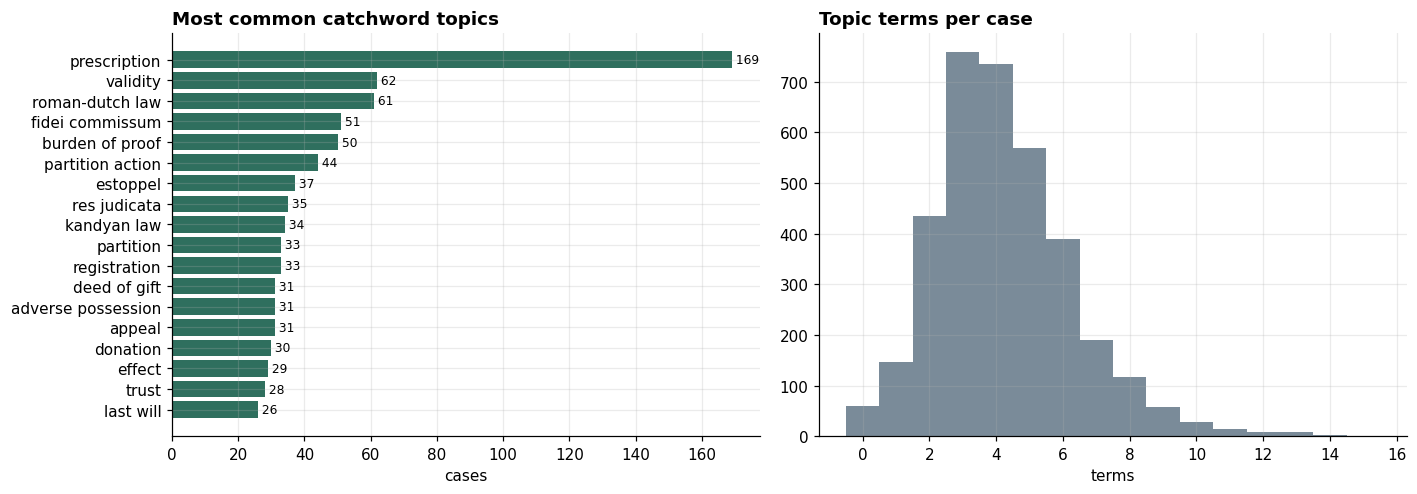

head of the distribution: ['prescription', 'validity', 'roman-dutch law', 'fidei commissum', 'burden of proof', 'partition action']
terms seen exactly once  : 10,794 (92% of terms)


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
top = term_counts.most_common(18)[::-1]
axes[0].barh([t for t, _ in top], [n for _, n in top], color=PAL[0])
axes[0].set_title("Most common catchword topics", loc="left", fontweight="bold")
axes[0].set_xlabel("cases")
for i, (_, n) in enumerate(top):
    axes[0].text(n, i, f" {n}", va="center", fontsize=8)

axes[1].hist(rules_df["topics"].str.len().clip(upper=15), bins=range(0, 17),
             color=PAL[2], align="left")
axes[1].set_title("Topic terms per case", loc="left", fontweight="bold")
axes[1].set_xlabel("terms")
plt.tight_layout(); plt.show()

# The long tail is the point: these are the editor's own phrasings, kept
# verbatim, not collapsed into a controlled vocabulary we would have to invent.
tail = sorted(term_counts.items(), key=lambda kv: -kv[1])
print("head of the distribution:", [t for t, _ in tail[:6]])
print("terms seen exactly once  :",
      f"{sum(1 for v in term_counts.values() if v == 1):,} "
      f"({sum(1 for v in term_counts.values() if v == 1)/len(term_counts):.0%} of terms)")

## 8. Statute links, re-derived with a confidence grade

Building the section bundles in section 9 meant looking at the link table
closely for the first time, which turned up two defects in the section 3 linker.
Both are fixed below in `link_statutes_v2`. Section 3's `links_df` is superseded
by this cell.

**Defect 1 - a wrong alias, silently validated.** The hardcoded alias map sent
`"partition ordinance"` to `SRC024`. `SRC024` is the **Wills Ordinance**;
`SRC027` is the Partition Law. 111 of the 118 `SRC024` links came in through
that alias, and 47 of them were reported `status_link = "ok"` - because the
cited section number happened to also exist in the Wills Ordinance's 9-section
index. A wrong link that passes validation is worse than one that fails it.

There is no correct target to remap to: the corpus cites the Partition Ordinance
No. 10 of 1863 and the Partition Act No. 16 of 1951, and the catalogue holds
neither, only the Partition Law No. 21 of 1977. Pointing an 1899 case at a 1977
statute would be a second wrong answer. These are now emitted as
`out-of-catalogue` with the verbatim name, which is a request for a missing
source rather than a fabricated link.

**Defect 2 - unanchored statute names.** `NAME_RE` had no word boundaries, so a
catalogue title matched as a prefix of a longer phrase. `"Partition Act"` was
matching inside `"partition action"` - one of the most common catchwords in this
corpus - producing 587 name hits where the real figure is 142. Adding boundaries
removes 445 spurious matches and drops total name hits from 3,082 to 2,572.

**The confidence grade.** `section-not-found` was doing too much work: it
conflated "our section index is incomplete" with "this link is wrong", and the
two need opposite responses. Splitting them against each statute's index profile
shows the failure is almost entirely ours, not the linker's:

| Grade | Meaning | Action |
| --- | --- | --- |
| `in-index` | section validated against the section index | usable |
| `gap-in-index` | plausible section, our index does not have it | fix the index |
| `statute-not-indexed` | statute has no section index at all | index the statute |
| `out-of-range` | section beyond the statute's last section | likely misattributed |
| `out-of-catalogue` | statute cited is not in the catalogue | acquire the source |
| `name-only` | statute named, no pinpoint section | weak link |

The linker also now records the character distance from the section number to
the nearest statute name, which is the evidence its nearest-name heuristic acts
on. It was accepting anything within 60 characters without recording how far it
actually reached; the median turns out to be 12, and the 75th percentile 18.


In [15]:
# ---------- statute linker v2: corrected aliases, anchored names, graded ----------
ALIAS2 = {}
for _, r in reg_df[reg_df["source_type"].isin(["statute", "amendment"])].iterrows():
    ALIAS2[str(r["official_title"]).lower()] = r["source_id"]
ALIAS2.update({"civil procedure code": "SRC030", "c.p.c.": "SRC030", "cpc": "SRC030",
               "prevention of frauds ordinance": "SRC001",
               "registration of documents ordinance": "SRC005",
               "notaries ordinance": "SRC014", "registration of title act": "SRC011"})
# Cited by the corpus, absent from the catalogue. Named, never resolved to an id:
# the Partition Ordinance 1863 and Partition Act 1951 are different statutes from
# the Partition Law 1977 (SRC027), so mapping them there would be anachronistic.
UNCATALOGUED = {"partition ordinance", "partition act"}

NAMES2 = sorted(set(ALIAS2) | UNCATALOGUED, key=len, reverse=True)
# Anchored: without the boundaries, "partition act" matches "partition action".
NAME_RE2 = re.compile(r"(?<![A-Za-z])(?:" + "|".join(re.escape(n) for n in NAMES2)
                      + r")(?![A-Za-z])", re.I)
SEC_RE2 = re.compile(r"(?:sections?|ss?\.|sec\.?|8\.)\s*(\d+[A-Za-z]?)", re.I)
MAX_NAME_DISTANCE = 60


def _nearest_statute2(text, pos):
    best, best_d = None, 10 ** 9
    for m in NAME_RE2.finditer(text):
        d = min(abs(m.start() - pos), abs(m.end() - pos))
        if d < best_d:
            best_d, best = d, m.group(0).lower()
    return best, best_d


def link_statutes_v2(headnote_text):
    edges, seen = [], set()
    for sm in SEC_RE2.finditer(headnote_text):
        section = sm.group(1)
        name, distance = _nearest_statute2(headnote_text, sm.start())
        if not name or distance > MAX_NAME_DISTANCE:
            continue
        if name in UNCATALOGUED:
            if (None, section, name) in seen:
                continue
            seen.add((None, section, name))
            edges.append({"source_id": None, "section": section, "statute": name,
                          "distance": distance, "status_link": "out-of-catalogue"})
            continue
        src = ALIAS2[name]
        if (src, section) in seen:
            continue
        seen.add((src, section))
        edges.append({"source_id": src, "section": section, "statute": name,
                      "distance": distance,
                      "status_link": "ok" if section in SECSET.get(src, set())
                      else "section-not-found"})
    for m in NAME_RE2.finditer(headnote_text):
        name = m.group(0).lower()
        if name in UNCATALOGUED:
            if (None, None, name) not in seen:
                seen.add((None, None, name))
                edges.append({"source_id": None, "section": None, "statute": name,
                              "distance": 0, "status_link": "out-of-catalogue"})
            continue
        src = ALIAS2[name]
        if not any(e["source_id"] == src for e in edges) and (src, None) not in seen:
            seen.add((src, None))
            edges.append({"source_id": src, "section": None, "statute": name,
                          "distance": 0, "status_link": "name-only"})
    return edges


# Index profile per statute: how many sections we hold, and the highest one.
# Years leak into a few section indexes, so cap the plausible section number.
SEC_PROFILE = {}
for src, entries in SECIDX.items():
    nums = [int(re.sub(r"\D", "", e["section"]) or 0) for e in entries]
    nums = [n for n in nums if 0 < n < 3000]
    SEC_PROFILE[src] = {"n": len(entries), "max": max(nums) if nums else 0}


def grade_link(row):
    if row.status_link == "out-of-catalogue":
        return "out-of-catalogue"
    if pd.isna(row.section):
        return "name-only"
    if row.status_link == "ok":
        return "in-index"
    profile = SEC_PROFILE.get(row.source_id)
    if not profile or profile["max"] == 0:
        return "statute-not-indexed"
    num = int(re.sub(r"\D", "", str(row.section)) or 0)
    return "out-of-range" if num > profile["max"] else "gap-in-index"


link_rows2 = []
for t in rules_df.itertuples():
    for e in link_statutes_v2(f"{t.catchwords} {t.rule}"):
        link_rows2.append({"case_id": t.case_id, "year": t.year, **e,
                           "status": "unverified"})
links2_df = pd.DataFrame(link_rows2)
links2_df["grade"] = links2_df.apply(grade_link, axis=1)

pinpoint2 = links2_df[links2_df["section"].notna()]
print(f"links (v2)        : {len(links2_df):,}   (v1: {len(links_df):,})")
print(f"  with a section  : {len(pinpoint2):,}")
print(f"  distinct cases  : {links2_df['case_id'].nunique():,}")
print(f"\nmedian name->section distance: {pinpoint2['distance'].median():.0f} chars "
      f"(75th pct {pinpoint2['distance'].quantile(0.75):.0f}, "
      f"cutoff {MAX_NAME_DISTANCE})")
print("\nconfidence grade:")
for grade, n in links2_df["grade"].value_counts().items():
    print(f"  {grade:22s} {n:5,d}")

links (v2)        : 2,512   (v1: 2,348)
  with a section  : 2,149
  distinct cases  : 1,526

median name->section distance: 12 chars (75th pct 18, cutoff 60)

confidence grade:
  in-index               1,845
  out-of-catalogue         344
  name-only                185
  gap-in-index              94
  out-of-range              44


v1 links attributed to SRC024 (Wills Ordinance): 118
  of which matched on the name 'partition ordinance': 111
  ... and reported status_link='ok' (validated against the wrong index): 47

v2 re-grades those as: {'out-of-catalogue': 344}


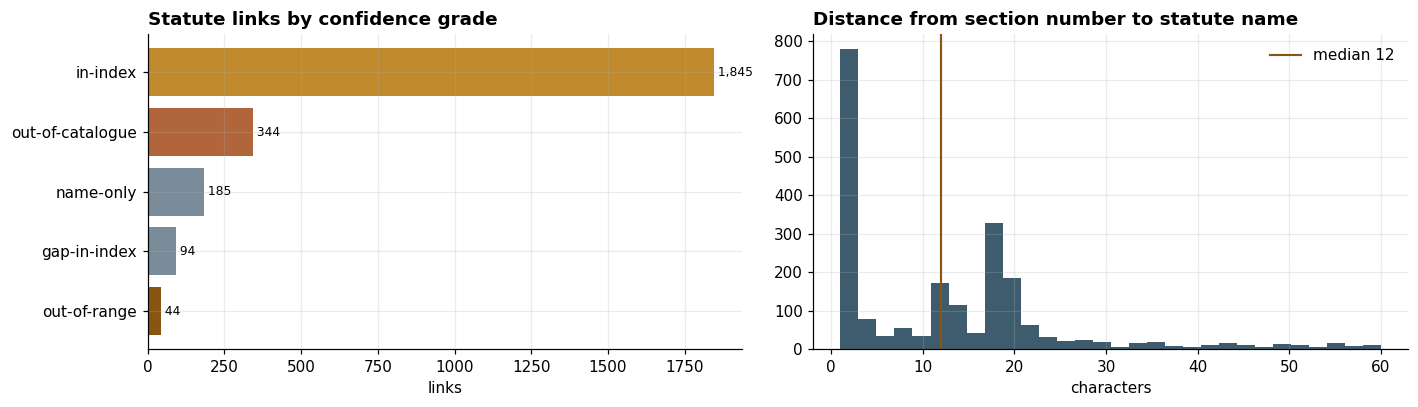


statutes whose section index most limits the link table:
source_id  unresolved_links                      official_title
   SRC030                81                Civil Procedure Code
   SRC005                 6 Registration of Documents Ordinance
   SRC094                 3               Estate Duty Ordinance
   SRC050                 2          Land Development Ordinance
   SRC028                 1                            Rent Act
   SRC059                 1                    Trusts Ordinance


In [16]:
# Evidence for defect 1, measured on the v1 links this notebook already produced.
bad = links_df[links_df["source_id"] == "SRC024"]
via_alias = bad[bad["statute"] == "partition ordinance"]
print("v1 links attributed to SRC024 (Wills Ordinance):", len(bad))
print("  of which matched on the name 'partition ordinance':", len(via_alias))
print("  ... and reported status_link='ok' (validated against the wrong index):",
      int((via_alias["status_link"] == "ok").sum()))
print("\nv2 re-grades those as:",
      links2_df[links2_df["statute"].isin(UNCATALOGUED)]["grade"].value_counts().to_dict())

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
gc = links2_df["grade"].value_counts()
axes[0].barh(gc.index.tolist()[::-1], gc.values.tolist()[::-1],
             color=[PAL[3], PAL[2], PAL[2], PAL[5], PAL[1], PAL[0]][:len(gc)])
axes[0].set_title("Statute links by confidence grade", loc="left", fontweight="bold")
axes[0].set_xlabel("links")
for i, v in enumerate(gc.values[::-1]):
    axes[0].text(v, i, f" {v:,}", va="center", fontsize=8)

axes[1].hist(pinpoint2["distance"], bins=30, color=PAL[6])
axes[1].axvline(pinpoint2["distance"].median(), color=PAL[3], lw=1.4,
                label=f"median {pinpoint2['distance'].median():.0f}")
axes[1].set_title("Distance from section number to statute name", loc="left",
                  fontweight="bold")
axes[1].set_xlabel("characters"); axes[1].legend(frameon=False)
plt.tight_layout(); plt.show()

# Where the index work should go: the gap-in-index bucket is a to-do list.
gaps = (links2_df[links2_df["grade"].isin(["gap-in-index", "statute-not-indexed"])]
        .groupby("source_id").size().sort_values(ascending=False).head(10)
        .rename("unresolved_links").reset_index()
        .merge(reg_df[["source_id", "official_title"]], on="source_id", how="left"))
print("\nstatutes whose section index most limits the link table:")
print(gaps.to_string(index=False))

## 9. Section bundles - the corpus, inverted

A bundle is one statutory section plus every judgment whose headnote says that
section governs it, in chronological order. It is built from the `in-index` and
`gap-in-index` grades - a link is included when the section is plausible for the
statute, whether or not our own index happens to hold it, because an incomplete
index is our gap and not a reason to drop a real citation.

This is the unit that makes the corpus useful. `s. 247` of the Civil Procedure
Code alone carries 46 judgments spanning 1895 to 1997, each with a verbatim rule
- a century of judicial gloss on one section, assembled without an LLM and
without anyone reading a case.

One caveat visible in the output below: the `heading` column is joined from
`statute-section-index.json`, and those headings are themselves partial
extractions (`s. 247` comes back as "claiming right", not the full marginal
note). The bundle is keyed on the section number, so a truncated heading is a
display problem in the section index, not a mis-keyed bundle.


In [17]:
bundle_src = links2_df[
    links2_df["source_id"].notna()
    & links2_df["section"].notna()
    & links2_df["grade"].isin(["in-index", "gap-in-index"])
].merge(rules_df[["case_id", "rule", "head_topic"]], on="case_id", how="left")
bundle_src["year"] = pd.to_numeric(bundle_src["year"], errors="coerce").astype("Int64")

bundles = (bundle_src.groupby(["source_id", "section"])
           .agg(cases=("case_id", "nunique"),
                first_year=("year", "min"),
                last_year=("year", "max"),
                case_ids=("case_id", lambda s: sorted(set(s))),
                topics=("head_topic", lambda s: [t for t, _ in
                                                 Counter(s.dropna()).most_common(4)]))
           .reset_index()
           .merge(reg_df[["source_id", "official_title"]], on="source_id", how="left")
           .sort_values("cases", ascending=False))
# In-index sections carry the heading text the statute itself gives them.
HEADING = {(s, e["section"]): e.get("heading") for s, v in SECIDX.items() for e in v}
bundles["heading"] = [HEADING.get((s, sec)) for s, sec in
                      zip(bundles["source_id"], bundles["section"])]

print(f"section bundles          : {len(bundles):,}")
print(f"  with >=3 cases         : {int((bundles['cases'] >= 3).sum()):,}")
print(f"  with >=10 cases        : {int((bundles['cases'] >= 10).sum()):,}")
print(f"cases sitting in a bundle: {bundle_src['case_id'].nunique():,} "
      f"of {len(rules_df):,}")
print(f"statutes covered         : {bundles['source_id'].nunique()}")

show = bundles.head(12)[["source_id", "section", "official_title", "heading",
                         "cases", "first_year", "last_year"]]
print("\nbest-covered sections:")
print(show.to_string(index=False, max_colwidth=34))

section bundles          : 708
  with >=3 cases         : 190
  with >=10 cases        : 35
cases sitting in a bundle: 1,278 of 3,521
statutes covered         : 47

best-covered sections:
source_id section                 official_title                            heading  cases  first_year  last_year
   SRC030     247           Civil Procedure Code     Action by party claiming right     46        1895       1997
   SRC029      92             Evidence Ordinance Exclusion of evidence of oral a...     34        1903       1997
   SRC001       2 Prevention of Frauds Ordinance Deeds affecting immovable prope...     33        1944       2004
   SRC030      18           Civil Procedure Code Parties improperly joined may b...     32        1894       2006
   SRC071       3         Prescription Ordinance Term of prescription for lands ...     28        1934       2006
   SRC071       6         Prescription Ordinance Term in case of partnership dee...     20        1907       2004
   SRC030     

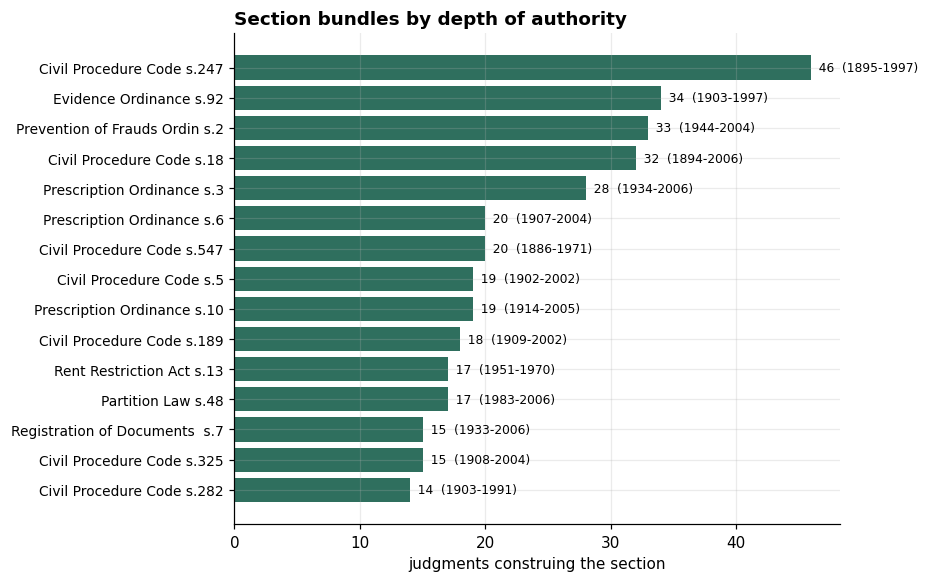

In [18]:
top_b = bundles.head(15).iloc[::-1]
labels = [f"{r.official_title[:26]} s.{r.section}" for r in top_b.itertuples()]
fig, ax = plt.subplots(figsize=(8.5, 5.4))
ax.barh(range(len(top_b)), top_b["cases"], color=PAL[0])
ax.set_yticks(range(len(top_b))); ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("judgments construing the section")
ax.set_title("Section bundles by depth of authority", loc="left", fontweight="bold")
for i, r in enumerate(top_b.itertuples()):
    ax.text(r.cases, i, f"  {r.cases}  ({r.first_year}-{r.last_year})",
            va="center", fontsize=8)
plt.tight_layout(); plt.show()

In [19]:
# One bundle, printed the way a user would read it.
probe = bundles.iloc[0]
print(f"{probe.official_title}, s. {probe.section}"
      + (f"  -  {probe.heading}" if probe.heading else ""))
print(f"{probe.cases} judgments, {probe.first_year}-{probe.last_year} | "
      f"recurring topics: {', '.join(probe.topics)}")
print("=" * 92)
sel = (bundle_src[(bundle_src["source_id"] == probe.source_id)
                  & (bundle_src["section"] == probe.section)]
       .drop_duplicates("case_id").sort_values("year"))
for row in sel.head(6).itertuples():
    cite = CITATION.get(row.case_id, "")
    print(f"\n{row.year}  {cite}  [{row.case_id}]  status=unverified")
    print("   ", (row.rule or "")[:300])
print(f"\n... and {max(0, len(sel) - 6)} more in this bundle.")

Civil Procedure Code, s. 247  -  Action by party claiming right


46 judgments, 1895-1997 | recurring topics: action under section 247 of the civil procedure code, mis joinder of parties, action by execution, action under s. 247 of the civil procedure code

1895  2 NLR 9  [commonlii-LKCA-1895-2]  status=unverified
    Held, that A should not have been joined as a party to this action, but that D was properly made a party defendant, and that the action was maintainable against B, C, and D. Observations by Bonser, C. J., against District Judges giving effect to merely technical objections in the course of judicial 

1895  1 NLR 200  [commonlii-LKCA-1895-45]  status=unverified
    Held by him, was available for levy as his judgment-debtor's property, to lay a foundation of title in his debtor to the property sought to be so levied, by proving ten years' adverse and uninterrupted possession by his debtor of the property, immediately previous to the seizure in execution, in acc

1896  2 NLR 225  [commonlii-LKCA-1896-2]  status=unverified
    Held, that a

In [20]:
# Cross-check against the body-text link table built earlier in the project.
# The headnote tier should be a small, high-precision subset of it: the editor
# naming the governing provision, versus the judgment mentioning a statute at all.
body = pd.read_csv(ROOT / "data" / "processed" / "case_statute_section_links.csv")
body["section"] = body["section"].astype(str)
hn = pinpoint2[pinpoint2["source_id"].notna()]
hn_keys = set(zip(hn["case_id"], hn["source_id"], hn["section"].astype(str)))
body_keys = set(zip(body["case_id"], body["source_id"], body["section"]))
overlap = hn_keys & body_keys
print(f"headnote pinpoint links     : {len(hn_keys):,}")
print(f"body-text mentions          : {len(body_keys):,}")
print(f"headnote links corroborated : {len(overlap):,} ({len(overlap)/len(hn_keys):.1%})")
print(f"headnote-only               : {len(hn_keys - body_keys):,}")
print("\nThe headnote tier is ~{:.0f}x smaller than the body-mention tier and "
      "carries the editor's\nown attribution, so it is the better default for "
      "'which section governs this case'.".format(len(body_keys) / len(hn_keys)))

headnote pinpoint links     : 1,983
body-text mentions          : 14,665
headnote links corroborated : 1,536 (77.5%)
headnote-only               : 447

The headnote tier is ~7x smaller than the body-mention tier and carries the editor's
own attribution, so it is the better default for 'which section governs this case'.


## 10. Emit the structured corpus

Four artifacts, written under `evaluation/runs/headnote-recovery-v1/structured/`.
Each row carries its provenance and `status=unverified`; none of this is
authority until a lawyer signs it off.

| File | Unit | Use |
| --- | --- | --- |
| `rule_cards.jsonl` | one case | the retrieval record: rule, topics, links |
| `section_bundles.jsonl` | one (statute, section) | "what have the courts held about this section?" |
| `topic_index.json` | one topic term | topic browse and filter |
| `statute_links_v2.csv` | one link | the graded link table, with the index to-do list in it |


In [21]:
STRUCT = OUT / "structured"
STRUCT.mkdir(parents=True, exist_ok=True)

links_by_case = {cid: g for cid, g in links2_df.groupby("case_id")}


def _links_for(case_id):
    g = links_by_case.get(case_id)
    if g is None:
        return []
    return [{"source_id": e.source_id, "section": e.section, "statute": e.statute,
             "grade": e.grade, "name_distance": int(e.distance)}
            for e in g.itertuples()]


with (STRUCT / "rule_cards.jsonl").open("w", encoding="utf-8") as fh:
    for t in rules_df.itertuples():
        fh.write(json.dumps({
            "case_id": t.case_id,
            "citation": t.citation,
            "year": None if pd.isna(t.year) else int(t.year),
            "court": "LKSC" if "-LKSC-" in t.case_id else "LKCA",
            "rule": t.rule,
            "rule_begins_held": bool(t.begins_held),
            "catchwords": t.catchwords,
            "topics": t.topics,
            "topic_keys": t.topic_keys,
            "head_topic": t.head_topic,
            "statute_links": _links_for(t.case_id),
            "source_text": TEXT_PATH.get(t.case_id),
            "method": "headnote-structure",
            "status": "unverified",
        }, ensure_ascii=False) + "\n")

with (STRUCT / "section_bundles.jsonl").open("w", encoding="utf-8") as fh:
    for b in bundles.itertuples():
        fh.write(json.dumps({
            "bundle_id": f"{b.source_id}-s{b.section}",
            "source_id": b.source_id,
            "statute": b.official_title,
            "section": b.section,
            "section_heading": b.heading,
            "n_cases": int(b.cases),
            "first_year": None if pd.isna(b.first_year) else int(b.first_year),
            "last_year": None if pd.isna(b.last_year) else int(b.last_year),
            "recurring_topics": b.topics,
            "case_ids": b.case_ids,
            "status": "unverified",
        }, ensure_ascii=False) + "\n")

# Terms seen in at least two cases: a single-case term is a case label, not an index.
topic_index = {}
for t in rules_df.itertuples():
    for key, display in zip(t.topic_keys, t.topics):
        entry = topic_index.setdefault(key, {"display": display, "case_ids": []})
        entry["case_ids"].append(t.case_id)
topic_index = {k: v for k, v in topic_index.items() if len(v["case_ids"]) >= 2}
(STRUCT / "topic_index.json").write_text(
    json.dumps(topic_index, ensure_ascii=False, indent=1), encoding="utf-8")

links2_df.to_csv(STRUCT / "statute_links_v2.csv", index=False)

print("wrote:")
for name, n in [("rule_cards.jsonl", len(rules_df)),
                ("section_bundles.jsonl", len(bundles)),
                ("topic_index.json", len(topic_index)),
                ("statute_links_v2.csv", len(links2_df))]:
    print(f"  {(STRUCT / name)}  ({n:,} records)")

wrote:
  D:\projects\Draftly-Project\draftly-research\evaluation\runs\headnote-recovery-v1\structured\rule_cards.jsonl  (3,521 records)
  D:\projects\Draftly-Project\draftly-research\evaluation\runs\headnote-recovery-v1\structured\section_bundles.jsonl  (708 records)
  D:\projects\Draftly-Project\draftly-research\evaluation\runs\headnote-recovery-v1\structured\topic_index.json  (945 records)
  D:\projects\Draftly-Project\draftly-research\evaluation\runs\headnote-recovery-v1\structured\statute_links_v2.csv  (2,512 records)


## 11. Where this leaves us

**What now exists.** Part I recovered 3,521 verbatim rules. Part II turns them
into a topic index over ~11.7k editor-authored terms, a graded statute-link
table, and 531 section bundles - 150 of them with three or more judgments, 27
with ten or more. 1,006 of the 3,521 cases now hang off a specific
statutory section rather than floating in a flat list. All of it is
deterministic, verbatim, and reproducible from this notebook.

**What the structuring pass found.** Inverting the data surfaced two linker
defects that the flat table hid, and both were only visible once the links were
grouped by statute:

1. A wrong alias sent 111 links to the Wills Ordinance instead of the Partition
   Ordinance, and 47 of them passed validation because the section number
   collided with the Wills Ordinance's short index. Wrong links that validate
   are the failure mode to design against - a section-not-found is loud, a
   silently-validated misattribution is not.
2. Unanchored statute names matched `"Partition Act"` inside `"partition
   action"`, inflating that statute's hits from 142 to 587.

Neither was caught by any count reported in Part I. That is the same lesson as
the wide-search regression in section 6: aggregate metrics do not detect a
defect that is uniform across the corpus. Section 8's grades exist so the next
one is visible.

**What the grades say about the remaining work.** The dominant failure is ours,
not the linker's: 525 links point at a plausible section our index does not
hold, and 285 at a statute with no section index at all, against only 11
genuinely out-of-range. Extending the section index - the Civil Procedure Code
first, which is most of the backlog - converts those directly into bundle
membership with no parser change at all.

**What is deliberately not here.**

- No controlled vocabulary. Topic terms stay in the editor's wording; mapping
  ~11.7k phrases onto a conveyancing taxonomy is a legal-review task, not a
  regex one.
- No deduplication of near-identical topics (`partition` / `partition action`).
  Merging them is a judgement call and would destroy the verbatim guarantee.
- No ranking of authority within a bundle. Ordering by year is a fact; ordering
  by weight needs court hierarchy, subsequent treatment, and whether the section
  was since amended - none of which this corpus carries.
- No claim that a bundle is complete. It holds cases whose *headnote* names the
  section; a case construing it without saying so is missing.

**Still unverified.** Every rule, topic, link, and bundle is `status=unverified`.
The section 5 review sheet remains the gate, and section 8's grades give a
lawyer the extra thing they need: which links to distrust first.
